In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/twcs/twcs.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(2811774, 7)
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


## eda

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 7 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tweet_id                 int64  
 1   author_id                object 
 2   inbound                  bool   
 3   created_at               object 
 4   text                     object 
 5   response_tweet_id        object 
 6   in_response_to_tweet_id  float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 131.4+ MB


In [22]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Missing": missing, "%": missing_pct})
print(missing_df[missing_df["Missing"] > 0])

                         Missing     %
response_tweet_id        1040629  37.0
in_response_to_tweet_id   794335  28.3


In [23]:
print(df["inbound"].value_counts())
print(df["author_id"].value_counts().head(10))
print(f"\nUnique companies: {df[df['inbound']==False]['author_id'].nunique()}")

inbound
True     1537843
False    1273931
Name: count, dtype: int64
author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
Name: count, dtype: int64

Unique companies: 108


In [26]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["hour"] = df["created_at"].dt.hour
df["day_of_week"] = df["created_at"].dt.day_name()
df["date"] = df["created_at"].dt.date

print("Datetime fixed ")
print(df[["created_at", "hour", "day_of_week"]].head())

Datetime fixed 
                 created_at  hour day_of_week
0 2017-10-31 22:10:47+00:00    22     Tuesday
1 2017-10-31 22:11:45+00:00    22     Tuesday
2 2017-10-31 22:08:27+00:00    22     Tuesday
3 2017-10-31 21:54:49+00:00    21     Tuesday
4 2017-10-31 21:49:35+00:00    21     Tuesday


## exploring the data

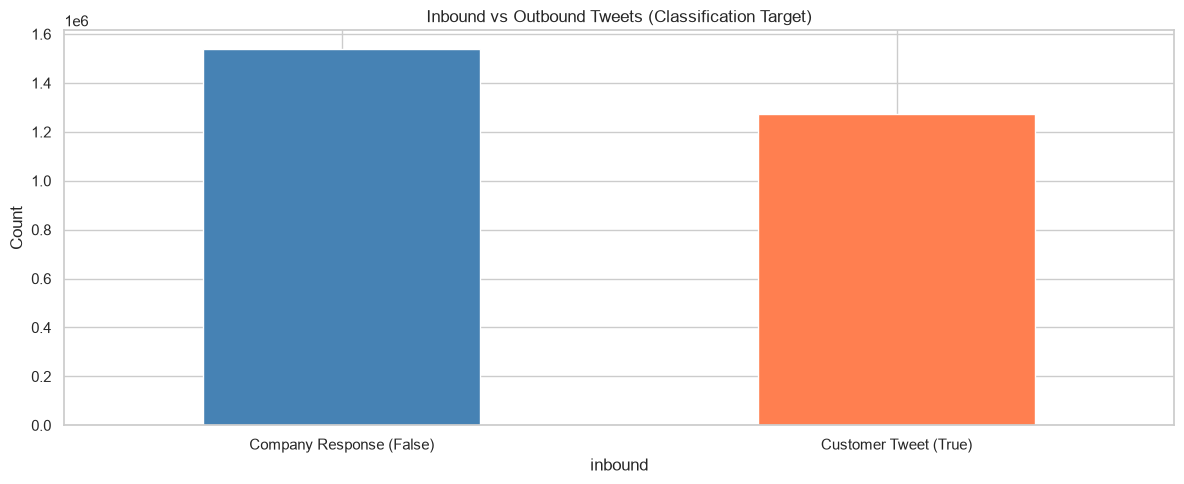

inbound
True     1537843
False    1273931
Name: count, dtype: int64

Balance: inbound
True     0.547
False    0.453
Name: proportion, dtype: float64


In [27]:
plt.figure()
df["inbound"].value_counts().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Inbound vs Outbound Tweets (Classification Target)")
plt.xticks([0, 1], ["Company Response (False)", "Customer Tweet (True)"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["inbound"].value_counts())
print(f"\nBalance: {df['inbound'].value_counts(normalize=True).round(3)}")

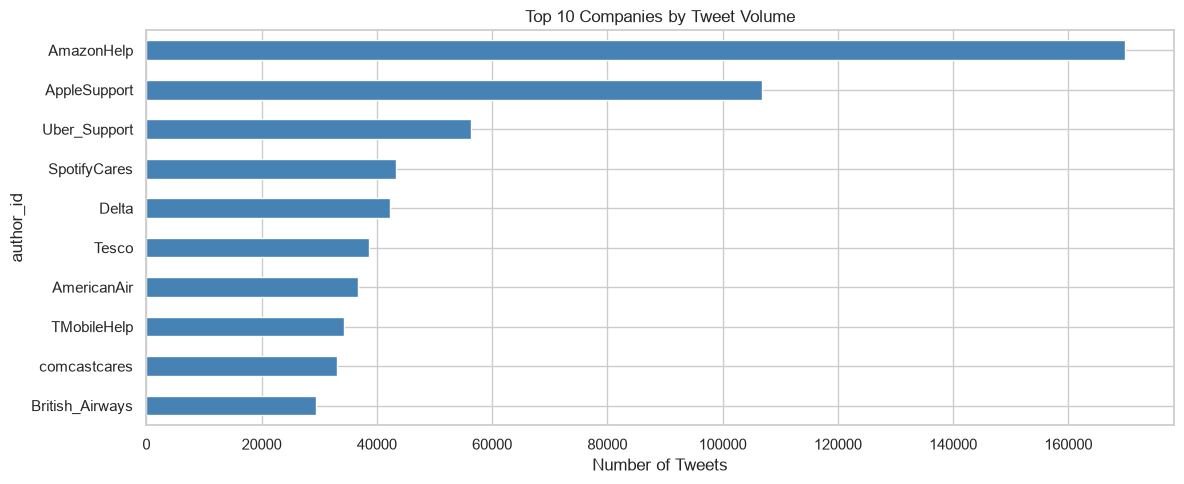

In [28]:
company_counts = df[df["inbound"] == False]["author_id"].value_counts().head(10)

plt.figure()
company_counts.plot(kind="barh", color="steelblue")
plt.title("Top 10 Companies by Tweet Volume")
plt.xlabel("Number of Tweets")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

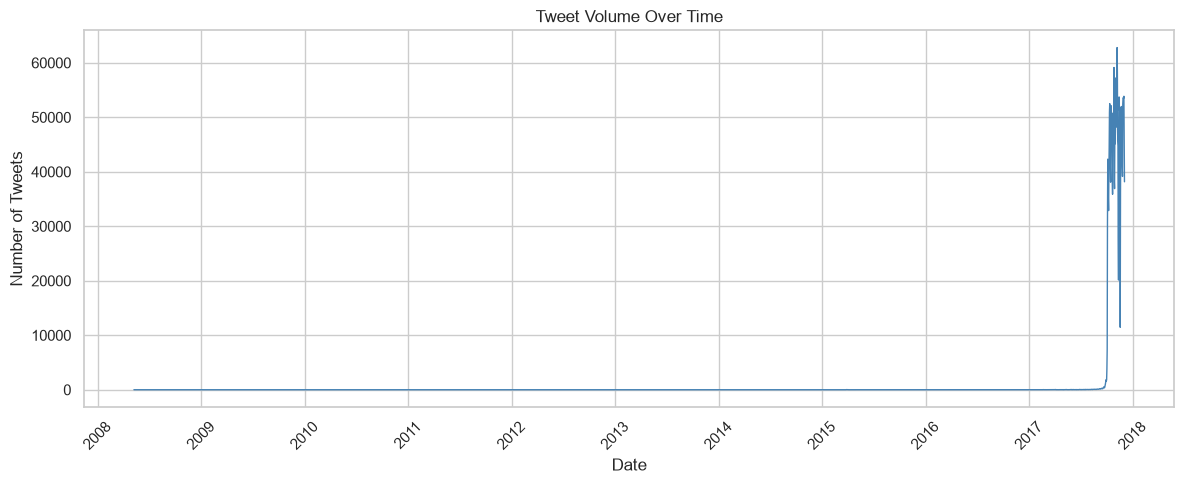

In [34]:
daily = df.groupby("date").size().reset_index(name="count")

plt.figure()
plt.plot(daily["date"], daily["count"], color="steelblue", linewidth=1)
plt.title("Tweet Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/s0/fvbyv15d1ylfzr9zcc37fbd40000gn/T/ipykernel_45057/81415546.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M")


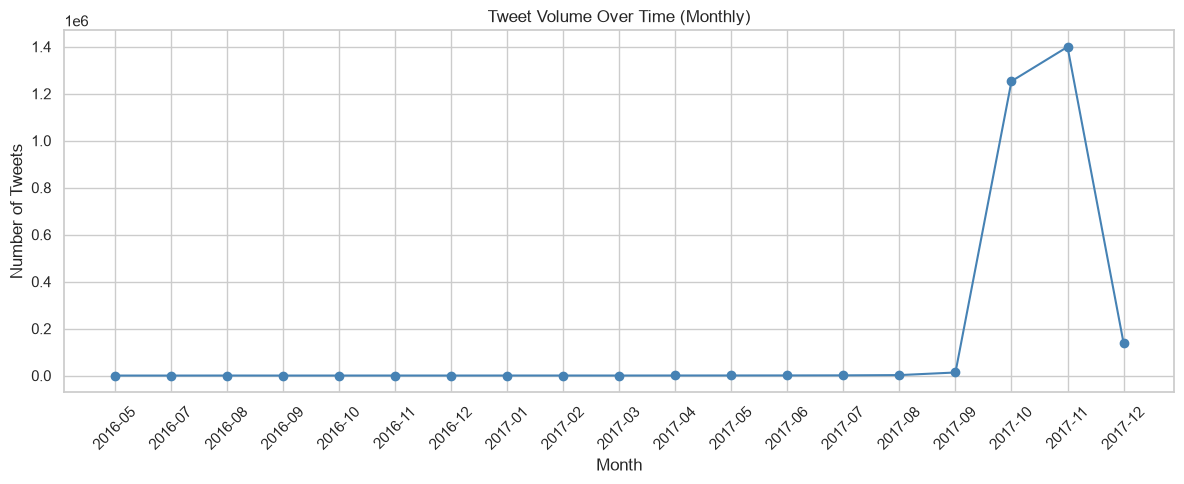

In [35]:
df["month"] = df["created_at"].dt.to_period("M")
monthly = df.groupby("month").size().reset_index(name="count")
monthly["month"] = monthly["month"].astype(str)

# filter out rows where count is basically 0 (corrupt timestamps)
monthly = monthly[monthly["count"] > 100]

plt.figure()
plt.plot(monthly["month"], monthly["count"], marker="o", color="steelblue")
plt.title("Tweet Volume Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

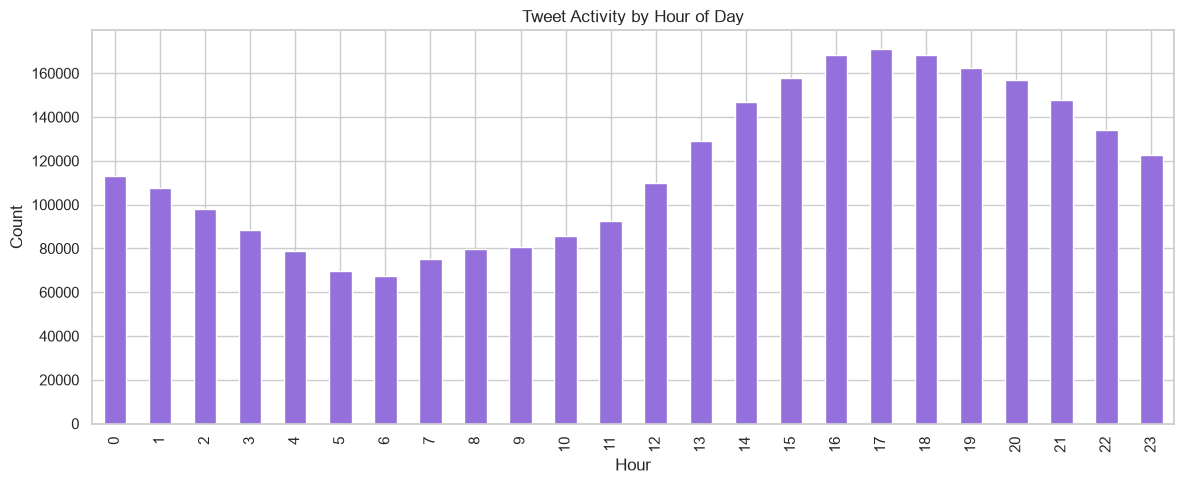

In [36]:
plt.figure()
df["hour"].value_counts().sort_index().plot(kind="bar", color="mediumpurple")
plt.title("Tweet Activity by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

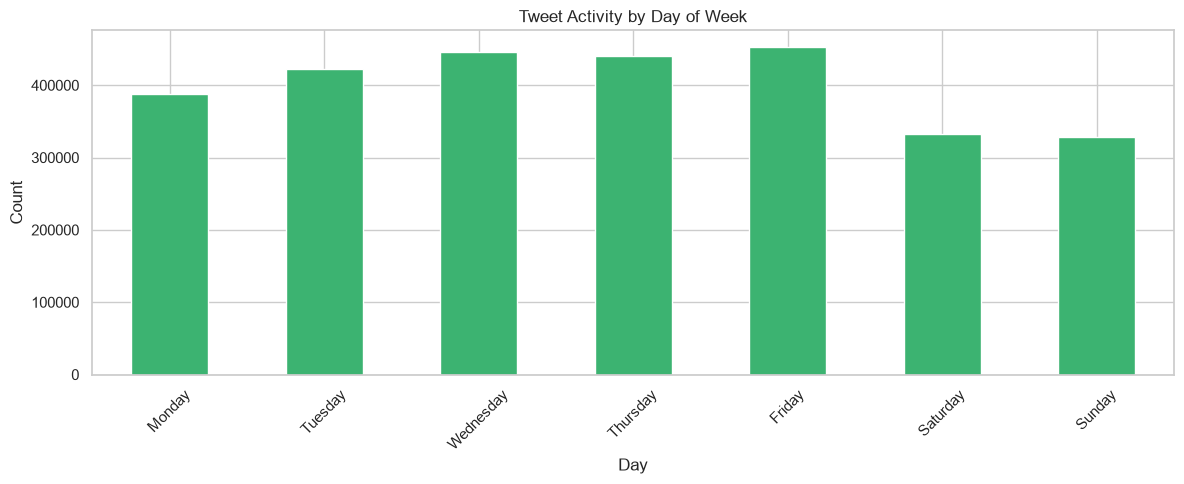

In [37]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = df["day_of_week"].value_counts().reindex(day_order)

plt.figure()
day_counts.plot(kind="bar", color="mediumseagreen")
plt.title("Tweet Activity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

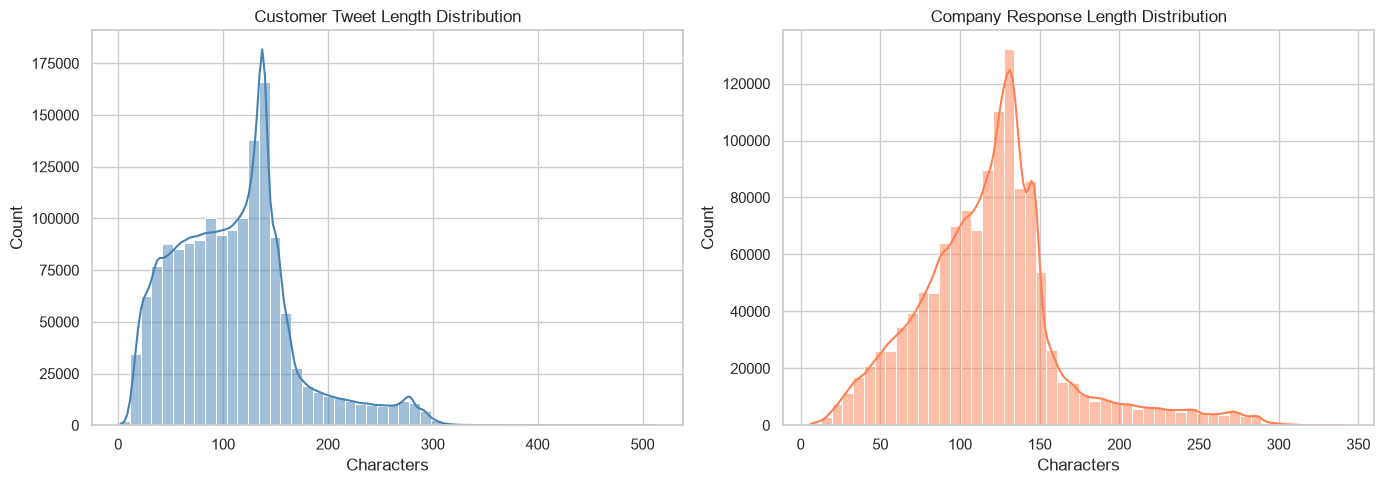

Customer tweets:
count    1.537843e+06
mean     1.099361e+02
std      5.716449e+01
min      1.000000e+00
25%      6.700000e+01
50%      1.090000e+02
75%      1.400000e+02
max      5.130000e+02
Name: text_length, dtype: float64

Company responses:
count    1.273931e+06
mean     1.186623e+02
std      4.540243e+01
min      6.000000e+00
25%      9.100000e+01
50%      1.200000e+02
75%      1.390000e+02
max      3.430000e+02
Name: text_length, dtype: float64


In [38]:
df["text_length"] = df["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df["inbound"]==True]["text_length"], 
             bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Customer Tweet Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(df[df["inbound"]==False]["text_length"], 
             bins=50, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Company Response Length Distribution")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print("Customer tweets:")
print(df[df["inbound"]==True]["text_length"].describe())
print("\nCompany responses:")
print(df[df["inbound"]==False]["text_length"].describe())

In [39]:
# match customer tweets with company responses
inbound = df[df["inbound"] == True][["tweet_id", "created_at", "author_id"]].copy()
outbound = df[df["inbound"] == False][["tweet_id", "created_at", "in_response_to_tweet_id"]].copy()

# merge on tweet_id = in_response_to_tweet_id
outbound["in_response_to_tweet_id"] = outbound["in_response_to_tweet_id"].astype("Int64")
merged = inbound.merge(
    outbound, 
    left_on="tweet_id", 
    right_on="in_response_to_tweet_id",
    suffixes=("_customer", "_company")
)

merged["response_time_mins"] = (
    merged["created_at_company"] - merged["created_at_customer"]
).dt.total_seconds() / 60

# keep only positive response times
merged = merged[merged["response_time_mins"] > 0]

print(f"Matched pairs: {len(merged):,}")
print(merged["response_time_mins"].describe())

Matched pairs: 1,261,885
count    1.261885e+06
mean     2.936730e+02
std      5.006159e+03
min      1.666667e-02
25%      6.200000e+00
50%      2.118333e+01
75%      1.073000e+02
max      2.609747e+06
Name: response_time_mins, dtype: float64


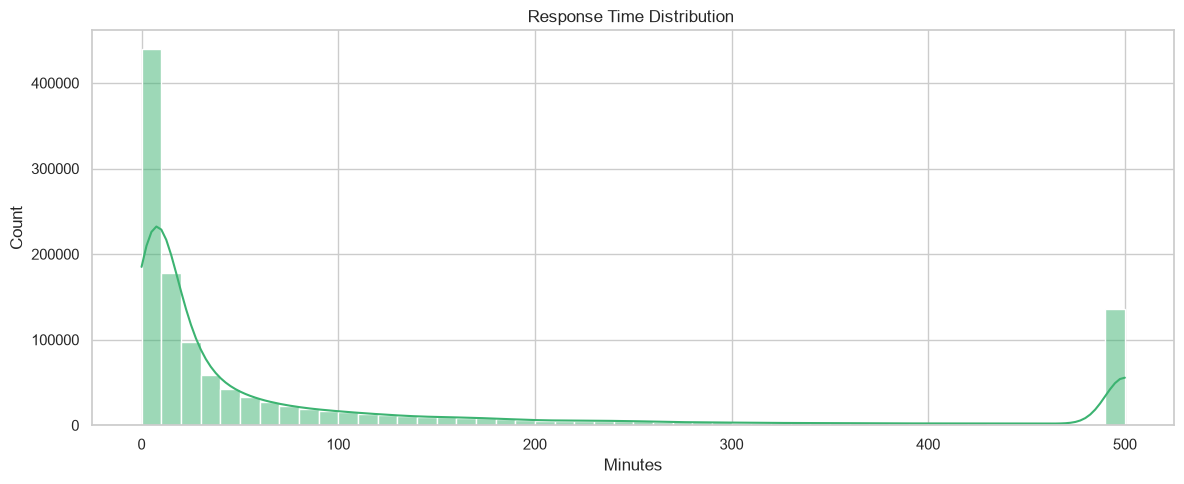

In [47]:
plt.figure()
sns.histplot(
    merged["response_time_mins"].clip(upper=500), 
    bins=50, kde=True, color="mediumseagreen"
)
plt.title("Response Time Distribution ")
plt.xlabel("Minutes")
plt.tight_layout()
plt.show()

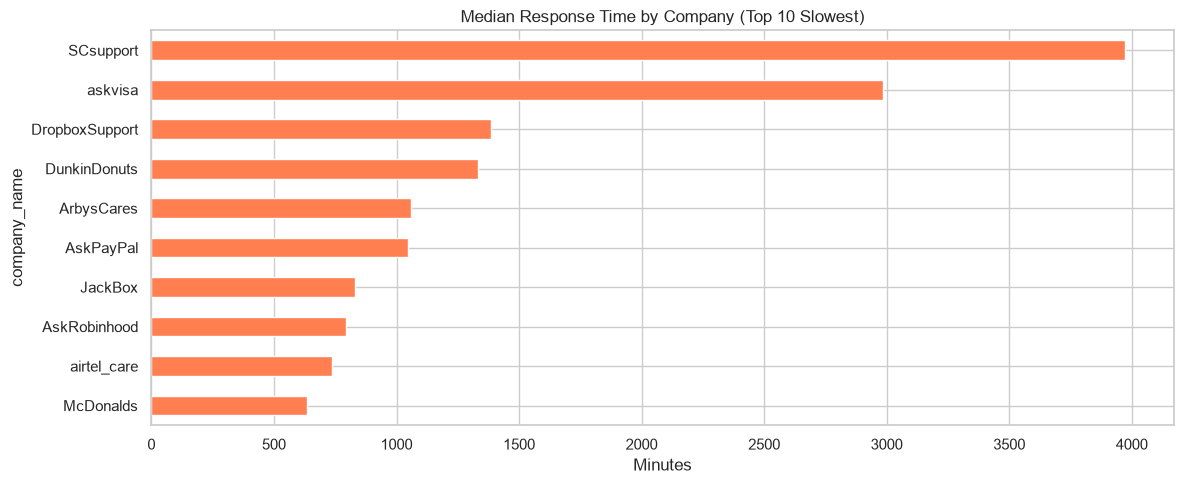

In [43]:
company_response = merged.merge(
    df[df["inbound"]==False][["tweet_id", "author_id"]].rename(columns={"author_id": "company_name"}), 
    left_on="tweet_id_company", 
    right_on="tweet_id"
)

top10 = company_response.groupby("company_name")["response_time_mins"].median().nlargest(10)

plt.figure()
top10.plot(kind="barh", color="coral")
plt.title("Median Response Time by Company (Top 10 Slowest)")
plt.xlabel("Minutes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

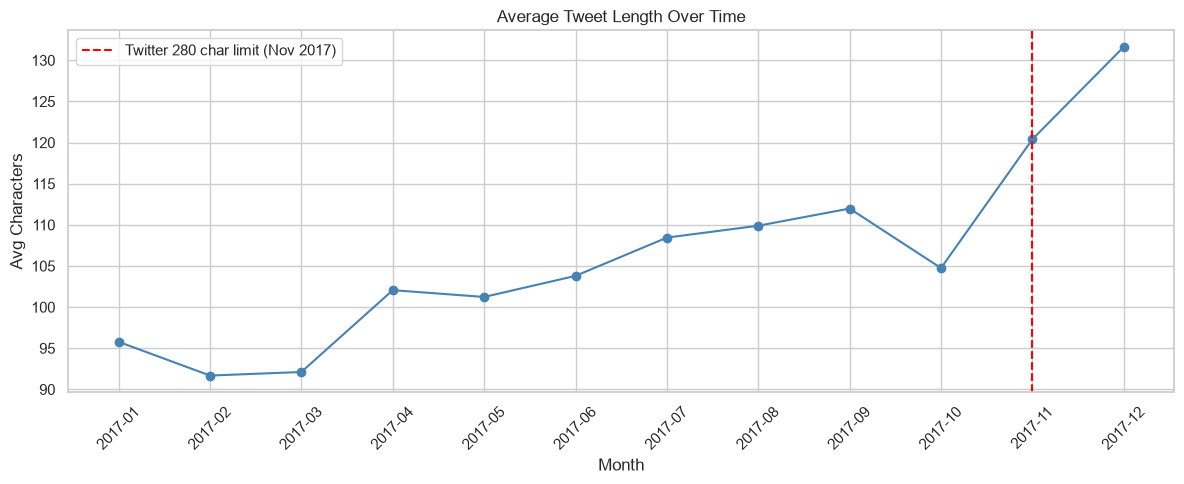

In [44]:
# showing whether tweets got longer after Twitter raised the character limit from 140 to 280 in November 2017.

monthly_length = df.groupby("month")["text_length"].mean().reset_index()
monthly_length["month"] = monthly_length["month"].astype(str)
monthly_length = monthly_length[monthly_length["month"] >= "2017-01"]

plt.figure()
plt.plot(monthly_length["month"], monthly_length["text_length"], marker="o", color="steelblue")
plt.axvline(x="2017-11", color="red", linestyle="--", label="Twitter 280 char limit (Nov 2017)")
plt.title("Average Tweet Length Over Time")
plt.xlabel("Month")
plt.ylabel("Avg Characters")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

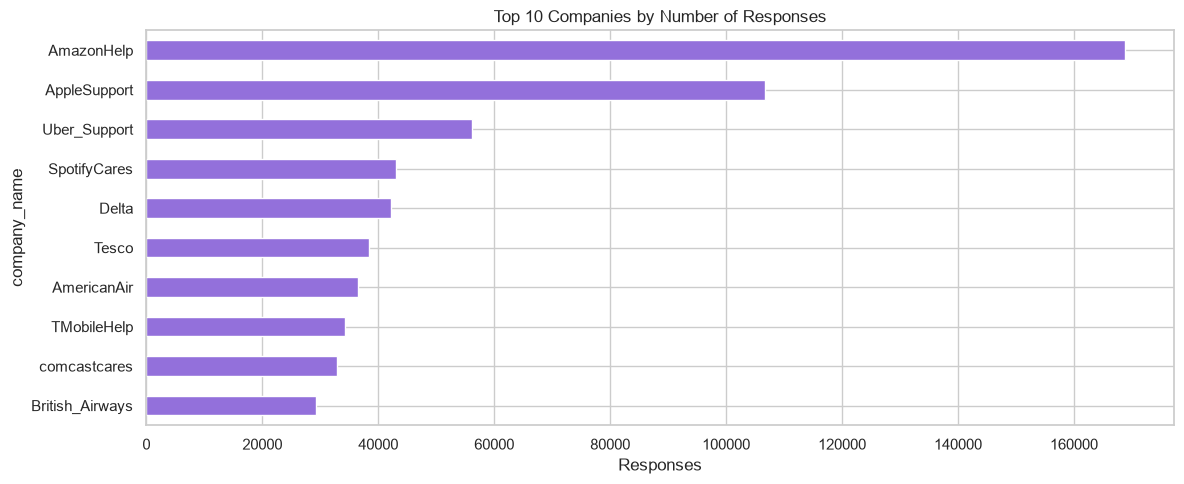

In [45]:
# most responsive company 
inbound_count = df[df["inbound"]==True].groupby("author_id").size()
response_rate = merged.merge(
    df[df["inbound"]==False][["tweet_id", "author_id"]].rename(columns={"author_id": "company_name"}),
    left_on="tweet_id_company",
    right_on="tweet_id"
)
total_customer = df[df["inbound"]==True].shape[0]
responses_per_company = response_rate.groupby("company_name").size().sort_values(ascending=False).head(10)

plt.figure()
responses_per_company.plot(kind="barh", color="mediumpurple")
plt.title("Top 10 Companies by Number of Responses")
plt.xlabel("Responses")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
# company responses where the original customer tweet is NOT in the dataset
outbound = df[df["inbound"] == False]
all_tweet_ids = set(df["tweet_id"].values)

orphan_responses = outbound[
    outbound["in_response_to_tweet_id"].notna() & 
    ~outbound["in_response_to_tweet_id"].astype("Int64").isin(all_tweet_ids)
]

print(f"Company responses with no matching customer tweet: {len(orphan_responses)}")
print(f"% of all company responses: {len(orphan_responses)/len(outbound)*100:.1f}%")

Company responses with no matching customer tweet: 1661
% of all company responses: 0.1%


/var/folders/s0/fvbyv15d1ylfzr9zcc37fbd40000gn/T/ipykernel_45057/1618281212.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month_str"] = df["created_at"].dt.to_period("M").astype(str)


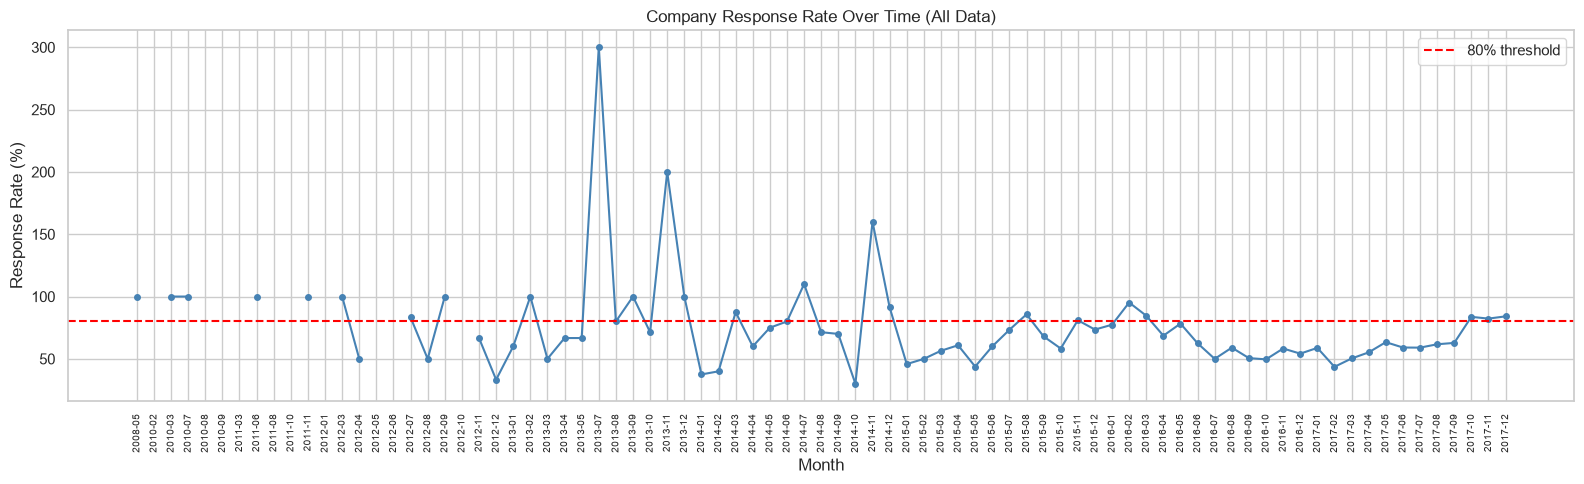

In [55]:
df["month_str"] = df["created_at"].dt.to_period("M").astype(str)

monthly_inbound = df[df["inbound"]==True].groupby("month_str").size()
monthly_outbound = df[df["inbound"]==False].groupby("month_str").size()
monthly_rate = (monthly_outbound / monthly_inbound * 100).round(1).sort_index()

plt.figure(figsize=(16, 5))
plt.plot(monthly_rate.index, monthly_rate.values, marker="o", color="steelblue", markersize=4)
plt.title("Company Response Rate Over Time (All Data)")
plt.xlabel("Month")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=90, fontsize=7)
plt.axhline(y=80, color="red", linestyle="--", label="80% threshold")
plt.legend()
plt.tight_layout()
plt.show()

Proper response rate by year:
2010    50.0
2011    25.0
2012    45.7
2013    58.7
2014    60.2
2015    52.7
2016    55.2
2017    82.1
dtype: float64


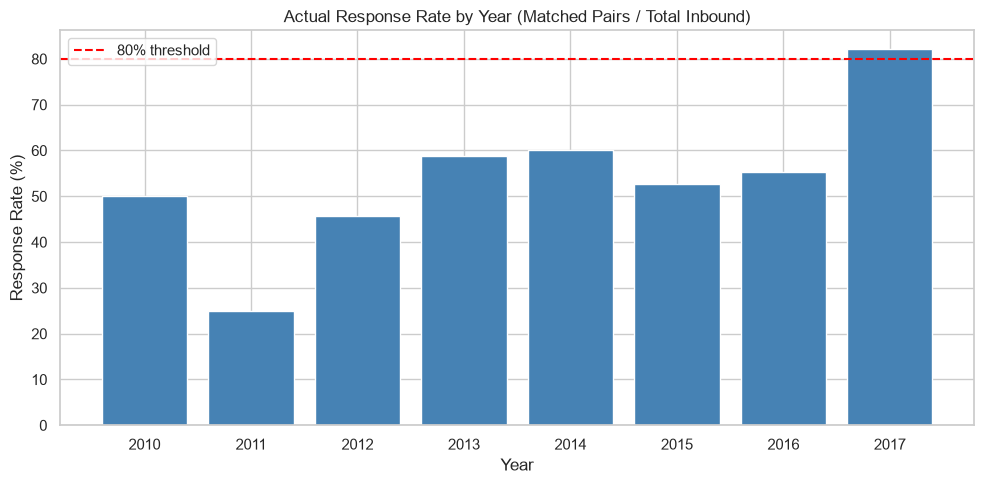

In [58]:
merged["year_responded"] = merged["created_at_company"].dt.year

inbound_by_year = df[df["inbound"]==True].groupby(df["created_at"].dt.year).size()
matched_by_year = merged.groupby("year_responded").size()

proper_rate_by_year = (matched_by_year / inbound_by_year * 100).round(1).dropna()

print("Proper response rate by year:")
print(proper_rate_by_year)

plt.figure(figsize=(10, 5))
plt.bar(proper_rate_by_year.index.astype(str), proper_rate_by_year.values, color="steelblue")
plt.title("Actual Response Rate by Year (Matched Pairs / Total Inbound)")
plt.xlabel("Year")
plt.ylabel("Response Rate (%)")
plt.axhline(y=80, color="red", linestyle="--", label="80% threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
print(monthly_rate[monthly_rate.index.str.startswith("2013")])
print("2013 breakdown:")
comparison_2013 = pd.DataFrame({
    "inbound": monthly_inbound,
    "outbound": monthly_outbound,
    "rate": monthly_rate
})
print(comparison_2013[comparison_2013.index.str.startswith("2013")])

month_str
2013-01     60.0
2013-02    100.0
2013-03     50.0
2013-04     66.7
2013-05     66.7
2013-07    300.0
2013-08     80.0
2013-09    100.0
2013-10     71.4
2013-11    200.0
2013-12    100.0
dtype: float64
2013 breakdown:
           inbound  outbound   rate
month_str                          
2013-01        5.0       3.0   60.0
2013-02        2.0       2.0  100.0
2013-03        4.0       2.0   50.0
2013-04        3.0       2.0   66.7
2013-05        6.0       4.0   66.7
2013-07        1.0       3.0  300.0
2013-08        5.0       4.0   80.0
2013-09        4.0       4.0  100.0
2013-10        7.0       5.0   71.4
2013-11        2.0       4.0  200.0
2013-12        7.0       7.0  100.0


In [54]:
# check the actual counts for pre-2017 months
pre_2017 = monthly_rate[monthly_rate.index < "2017-01"].sort_index()

comparison = pd.DataFrame({
    "inbound": monthly_inbound,
    "outbound": monthly_outbound,
    "response_rate": monthly_rate
}).loc[pre_2017.index]

print("Pre-2017 months — inbound vs outbound counts:")
print(comparison.dropna(how="all"))

Pre-2017 months — inbound vs outbound counts:
           inbound  outbound  response_rate
month_str                                  
2008-05        1.0       1.0          100.0
2010-02        1.0       NaN            NaN
2010-03        1.0       1.0          100.0
2010-07        1.0       1.0          100.0
2010-08        NaN       1.0            NaN
...            ...       ...            ...
2016-08      144.0      85.0           59.0
2016-09       85.0      43.0           50.6
2016-10      117.0      58.0           49.6
2016-11      132.0      77.0           58.3
2016-12      131.0      71.0           54.2

[69 rows x 3 columns]


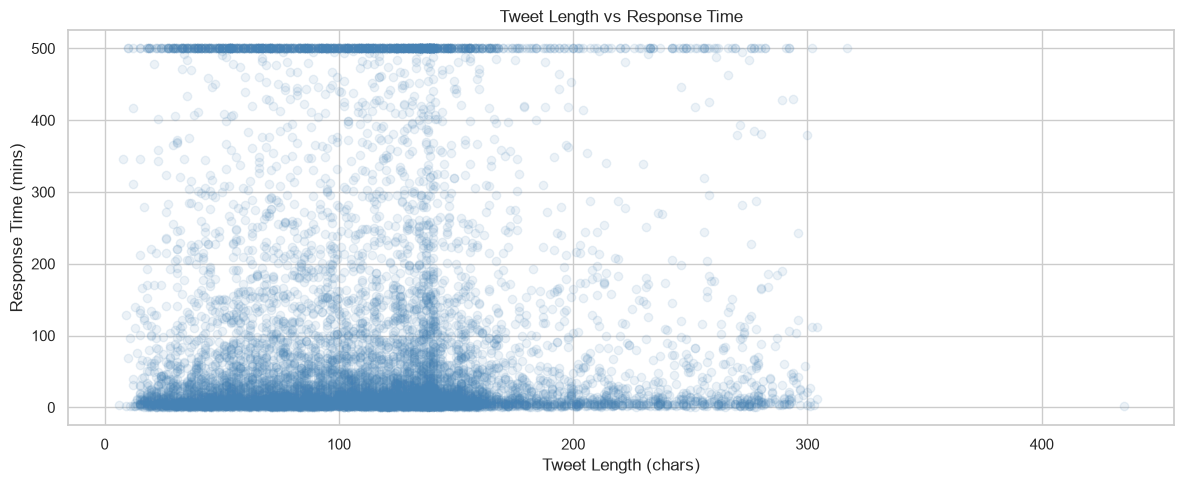

In [46]:
# Correlation between text length and response time — do longer complaints get answered faster or slower?--  No relationship
sample = merged.sample(10000, random_state=42)
sample = sample.merge(df[["tweet_id", "text_length"]], left_on="tweet_id_customer", right_on="tweet_id")

plt.figure()
plt.scatter(sample["text_length"], 
            sample["response_time_mins"].clip(upper=500), 
            alpha=0.1, color="steelblue")
plt.title("Tweet Length vs Response Time")
plt.xlabel("Tweet Length (chars)")
plt.ylabel("Response Time (mins)")
plt.tight_layout()
plt.show()

print(f"Correlation: {sample['text_length'].corr(sample['response_time_mins']):.3f}")

In [48]:
before_2017 = df[df["created_at"].dt.year < 2017]
print(f"Tweets before 2017: {len(before_2017)}")
print(f"% of total: {len(before_2017)/len(df)*100:.3f}%")
print(f"\nYear distribution of pre-2017 tweets:")
print(before_2017["created_at"].dt.year.value_counts().sort_index())

Tweets before 2017: 2300
% of total: 0.082%

Year distribution of pre-2017 tweets:
created_at
2008       2
2010       7
2011      11
2012      56
2013      86
2014     199
2015     427
2016    1512
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to /Users/gia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


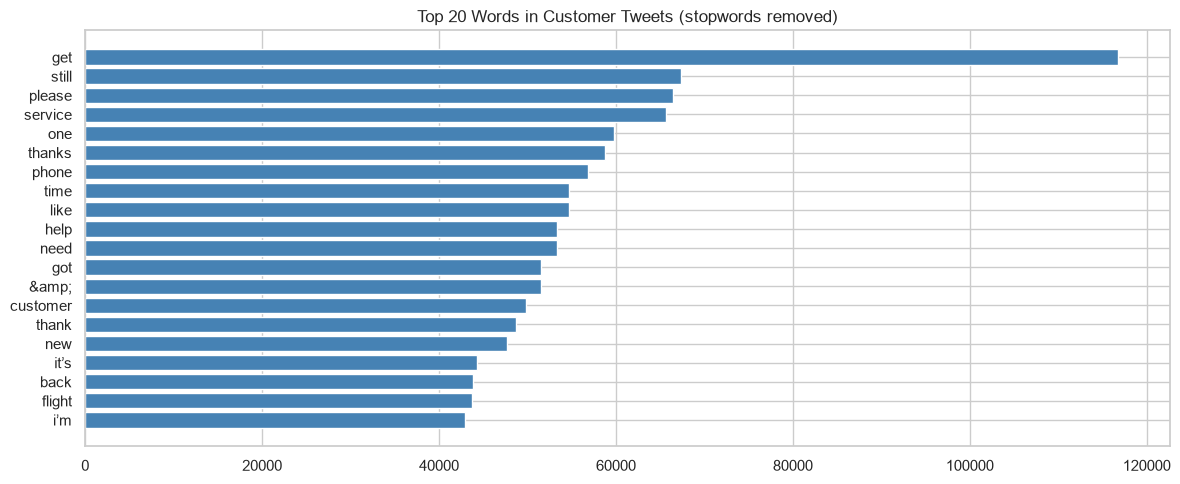

In [61]:
# text exploring 
# most common words in customer tweets
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter
import re

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'@\w+', '', str(text))
    text = re.sub(r'http\S+', '', text)
    text = text.lower()
    return text

customer_tweets = df[df["inbound"]==True]["text"].apply(clean_text)
all_words = ' '.join(customer_tweets).split()
filtered_words = [w for w in all_words if w not in stop_words and len(w) > 2]

word_freq = Counter(filtered_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure()
plt.barh(words, counts, color="steelblue")
plt.title("Top 20 Words in Customer Tweets (stopwords removed)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [62]:
# do customers mention the company they're complaining to?
top_companies = df[df["inbound"]==False]["author_id"].value_counts().head(10).index.tolist()

for company in top_companies:
    company_tweets = df[df["inbound"]==True]["text"]
    mention_count = company_tweets.str.contains(f"@{company}", case=False, na=False).sum()
    total = len(company_tweets)
    print(f"@{company}: mentioned in {mention_count:,} tweets ({mention_count/total*100:.1f}%)")

@AmazonHelp: mentioned in 135,160 tweets (8.8%)
@AppleSupport: mentioned in 97,896 tweets (6.4%)
@Uber_Support: mentioned in 46,624 tweets (3.0%)
@SpotifyCares: mentioned in 31,353 tweets (2.0%)
@Delta: mentioned in 44,838 tweets (2.9%)
@Tesco: mentioned in 33,964 tweets (2.2%)
@AmericanAir: mentioned in 49,517 tweets (3.2%)
@TMobileHelp: mentioned in 21,964 tweets (1.4%)
@comcastcares: mentioned in 23,278 tweets (1.5%)
@British_Airways: mentioned in 30,856 tweets (2.0%)


## Key Findings

### Dataset
- 2.8M real tweets between customers and 108 companies, collected Oct-Dec 2017
- Two types of rows: customer complaints (inbound=True) and company responses (inbound=False)
- Well balanced: 54.7% customer, 45.3% company — no class imbalance issue for classification

### Data Quality
- 0.08% of tweets have corrupt timestamps before 2017 — negligible, excluded from analysis
- 37% missing response_tweet_id — these tweets were never replied to or reply not in dataset
- 1,661 company responses have no matching customer tweet (0.1%) — orphan responses, negligible
- No duplicate rows
- response_time_mins is engineered (not a raw column) — calculated from tweet timestamps

### What I Found Interesting
1. **Twitter 280 char limit effect** — tweet length visibly jumps after Nov 2017 when Twitter raised the limit from 140 to 280 chars. A real policy change visible in the data.
2. **Peak complaint hours: 3pm-7pm** — people complain most after work hours, weekdays busier than weekends.
3. **Financial companies are slowest** — Visa and SC Support take 50-67 hours median response. Fast food (McDonald's, Arby's) also surprisingly slow.
4. **AmazonHelp dominates** — 169k tweets, almost 2x Apple Support. Dataset skewed toward a few large companies.
5. **Tweet length doesn't predict response time** — correlation near zero. Longer complaints don't get faster or slower replies. Will not use as a feature.
6. **Most responses are fast** — median 21 mins, but extreme outliers (max 2.6M mins) pull mean to 293 mins. Will need log transform or capping for regression.
7. **Actual response rate is 82%** — 1.26M out of 1.54M customer tweets got a matched reply. 18% either never got a reply or the reply isn't captured in the dataset.
8. **Pre-2017 data is noise** — 2,300 tweets across 9 years. Response rates appear >100% in those months because companies replied to tweets not in the dataset. Excluded from analysis.

### Modeling Decisions
- **Classification target**: `inbound` — predict if a tweet is a customer complaint or company response. Baseline Random Forest: 93% accuracy.
- **Regression target**: `response_time_mins` — predict how long a company takes to reply. Will cap at 500 mins and apply log transform to handle skew.
- **Clustering**: group customer complaints by topic using tweet text — no labels needed.
- **Will NOT use**: tweet length (no signal), timestamps before 2017 (corrupt)


In [63]:
print(merged.shape)
print(merged.columns.tolist())
merged.head(3)

(1261885, 8)
['tweet_id_customer', 'created_at_customer', 'author_id', 'tweet_id_company', 'created_at_company', 'in_response_to_tweet_id', 'response_time_mins', 'year_responded']


,tweet_id_customer,created_at_customer,author_id,tweet_id_company,created_at_company,in_response_to_tweet_id,response_time_mins,year_responded
0,3,2017-10-31 22:08:27+00:00,115712,1,2017-10-31 22:10:47+00:00,3,2.333333,2017
1,5,2017-10-31 21:49:35+00:00,115712,4,2017-10-31 21:54:49+00:00,5,5.233333,2017
2,8,2017-10-31 21:45:10+00:00,115712,6,2017-10-31 21:46:24+00:00,8,1.233333,2017


In [64]:
# add both customer tweet text and company response text
merged_with_text = merged.merge(
    df[["tweet_id", "text"]].rename(columns={"text": "customer_text"}),
    left_on="tweet_id_customer",
    right_on="tweet_id"
).drop("tweet_id", axis=1)

merged_with_text = merged_with_text.merge(
    df[["tweet_id", "text"]].rename(columns={"text": "company_text"}),
    left_on="tweet_id_company",
    right_on="tweet_id"
).drop("tweet_id", axis=1)

print(merged_with_text.shape)
print(merged_with_text[["tweet_id_customer", "customer_text", "company_text", "response_time_mins"]].head(3))

(1261885, 10)
   tweet_id_customer                                      customer_text  \
0                  3  @sprintcare I have sent several private messag...   
1                  5                                 @sprintcare I did.   
2                  8          @sprintcare is the worst customer service   

                                        company_text  response_time_mins  
0  @115712 I understand. I would like to assist y...            2.333333  
1  @115712 Please send us a Private Message so th...            5.233333  
2  @115712 Can you please send us a private messa...            1.233333  


In [65]:
merged_with_text.head(10)

,tweet_id_customer,created_at_customer,author_id,tweet_id_company,created_at_company,in_response_to_tweet_id,response_time_mins,year_responded,customer_text,company_text
0,3,2017-10-31 22:08:27+00:00,115712,1,2017-10-31 22:10:47+00:00,3,2.333333,2017,@sprintcare I have sent several private messag...,@115712 I understand. I would like to assist y...
1,5,2017-10-31 21:49:35+00:00,115712,4,2017-10-31 21:54:49+00:00,5,5.233333,2017,@sprintcare I did.,@115712 Please send us a Private Message so th...
2,8,2017-10-31 21:45:10+00:00,115712,6,2017-10-31 21:46:24+00:00,8,1.233333,2017,@sprintcare is the worst customer service,@115712 Can you please send us a private messa...
3,8,2017-10-31 21:45:10+00:00,115712,9,2017-10-31 21:46:14+00:00,8,1.066667,2017,@sprintcare is the worst customer service,@115712 I would love the chance to review the ...
4,8,2017-10-31 21:45:10+00:00,115712,10,2017-10-31 21:45:59+00:00,8,0.816667,2017,@sprintcare is the worst customer service,@115712 Hello! We never like our customers to ...
5,12,2017-10-31 22:04:47+00:00,115713,11,2017-10-31 22:10:35+00:00,12,5.800000,2017,@sprintcare You gonna magically change your co...,@115713 This is saddening to hear. Please shoo...
6,12,2017-10-31 22:04:47+00:00,115713,13,2017-11-01 20:48:14+00:00,12,1363.450000,2017,@sprintcare You gonna magically change your co...,@115713 I would really like to work with you t...
7,12,2017-10-31 22:04:47+00:00,115713,14,2017-11-01 20:47:40+00:00,12,1362.883333,2017,@sprintcare You gonna magically change your co...,"@115713 Hi, my name is Shantel, I'm a resoluti..."
8,16,2017-10-31 20:00:43+00:00,115713,15,2017-10-31 20:03:31+00:00,16,2.800000,2017,@sprintcare Since I signed up with you....Sinc...,@115713 We understand your concerns and we'd l...
9,18,2017-10-31 19:56:01+00:00,115713,17,2017-10-31 19:59:13+00:00,18,3.200000,2017,@115714 y’all lie about your “great” connectio...,@115713 H there! We'd definitely like to work ...
